# 💼 Adult Census Income Prediction

---

## 📌 Executive Summary

This project aims to build machine learning classification models (**KNN**, **Logistic Regression**, and **Naive Bayes**) to predict whether an individual's income exceeds **$50K/year** based on census profile features.

---

## 🛠️ Project Workflow

1. **Data Cleaning & Handling Missing Values**: Identifying missing indicators (`?`) and handling duplicates.
2. **Exploratory Data Analysis (EDA) & Feature Engineering**: Feature simplification, combining capital columns, and feature reduction.
3. **Data Encoding**: Applying `OrdinalEncoder` for binary columns and `OneHotEncoder` for multi-class categorical features post train-test split.
4. **Feature Scaling**: Scaling numerical variables using `RobustScaler` to handle extreme outliers.
5. **Model Training & Comparison**: Implementing KNN, Logistic Regression, and Naive Bayes classifiers.
6. **Evaluation**: Assessing model performance using **Accuracy**, **Precision**, **Recall**, and **Confusion Matrices**.

---

### Import Libraries
_______
import the libraries that will be used 
for data manipulation, visualization, preprocessing, 
model building, and model evaluation

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)

In [2]:
data = pd.read_csv("adult.csv")

In [3]:
data.shape

(48842, 15)

In [4]:
data.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [5]:
data.tail()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


## 🔍 Missing Values Analysis
______
Check for missing values across all dataset features.



In [6]:
data.isin(["?"]).sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [7]:
data.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [8]:
data["workclass"] = data["workclass"].replace("?",np.nan)
data["occupation"] = data["occupation"].replace("?",np.nan)
data["native-country"] = data["native-country"].replace("?",np.nan)

In [9]:
data.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

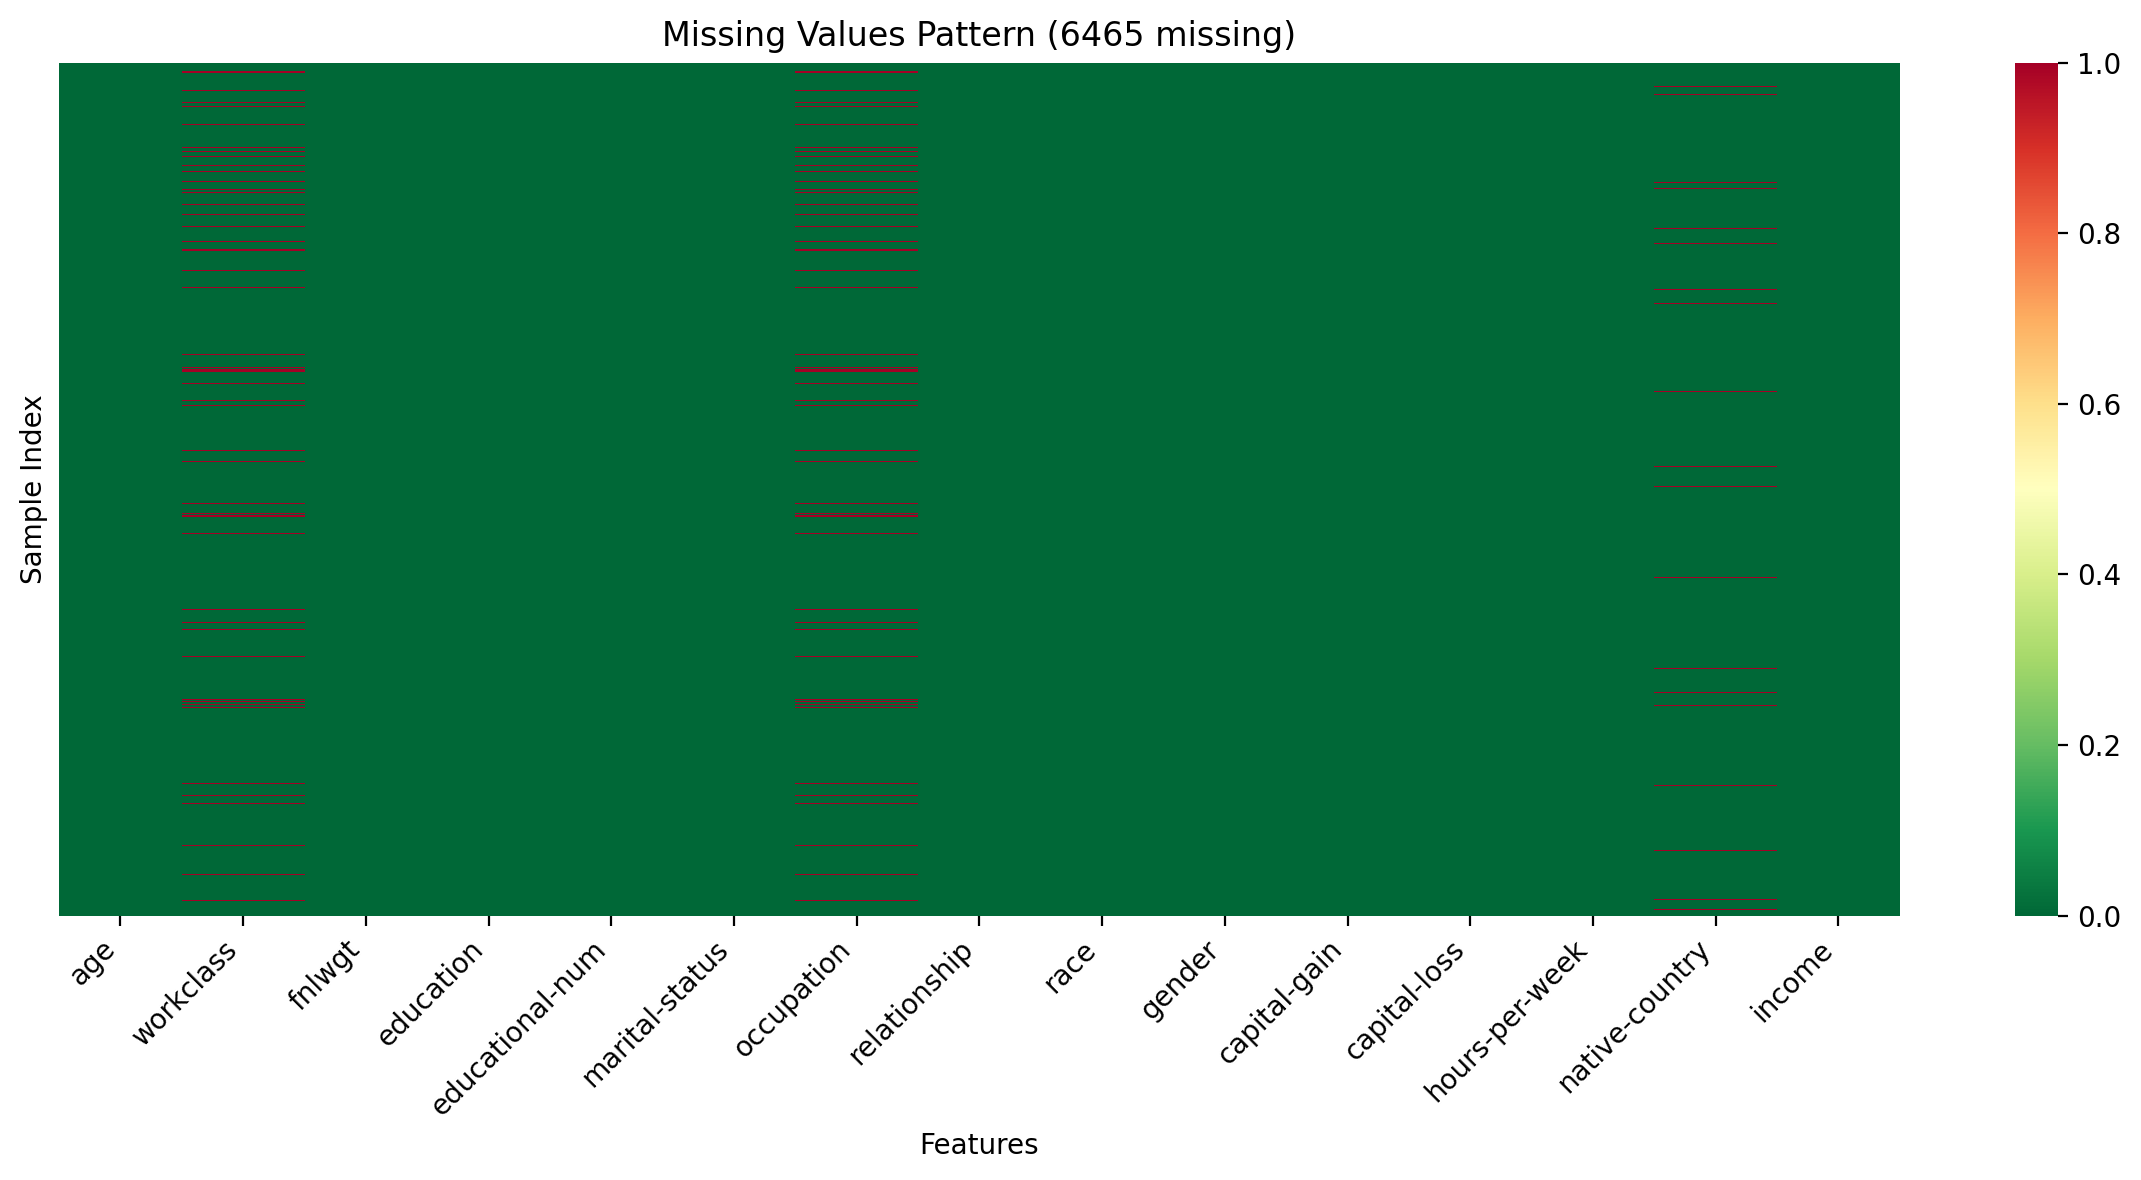

In [10]:
plt.figure(figsize=(12, 6), dpi=200)
sns.heatmap(data.isnull(), cbar=True, yticklabels=False, cmap='RdYlGn_r')
plt.xlabel('Features')
plt.ylabel('Sample Index')
plt.title(f'Missing Values Pattern ({data.isnull().sum().sum()} missing)')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        46043 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       46033 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   47985 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [12]:
data['workclass'] = data['workclass'].fillna('Unknown')
data['occupation'] = data['occupation'].fillna('Unknown')
data['native-country'] = data['native-country'].fillna('Unknown')

In [13]:
data.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [14]:
data.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,Unknown,227026,HS-grad,9,Never-married,Unknown,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


### 📝 Notes

* Missing values in this dataset were originally represented as `'?'` in `workclass`, `occupation`, and `native-country`.
* All `'?'` values were replaced with `np.nan` and imputed as `'Unknown'` to preserve dataset volume.
* No standard `NaN` values remain in the dataset after imputation.

## 👥 Duplicate Values
_____
Check whether the dataset contains duplicate rows.


In [15]:
data.duplicated().sum()

np.int64(52)

In [16]:
data = data.drop_duplicates()

In [17]:
data.duplicated().sum()

np.int64(0)

In [18]:
data.shape

(48790, 15)

### 📝 Notes

* Detected **52 duplicate rows** in the initial dataset inspection.
* Dropped all duplicate entries to prevent data bias and data leakage during evaluation.

## ⚙️ Data Cleaning & Feature Engineering
_______
Prepare existing features for analysis and machine learning models:


In [19]:
print(data["income"].value_counts(normalize=True))

income
<=50K    0.760586
>50K     0.239414
Name: proportion, dtype: float64


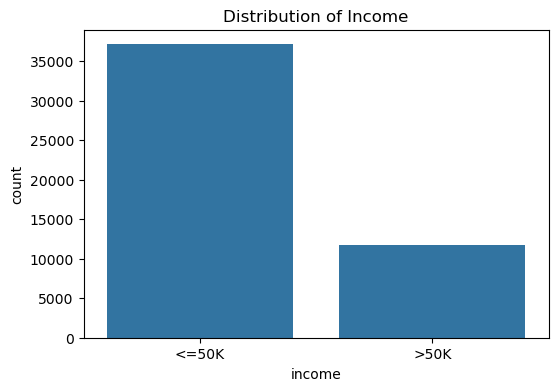

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='income')
plt.title('Distribution of Income')
plt.show()

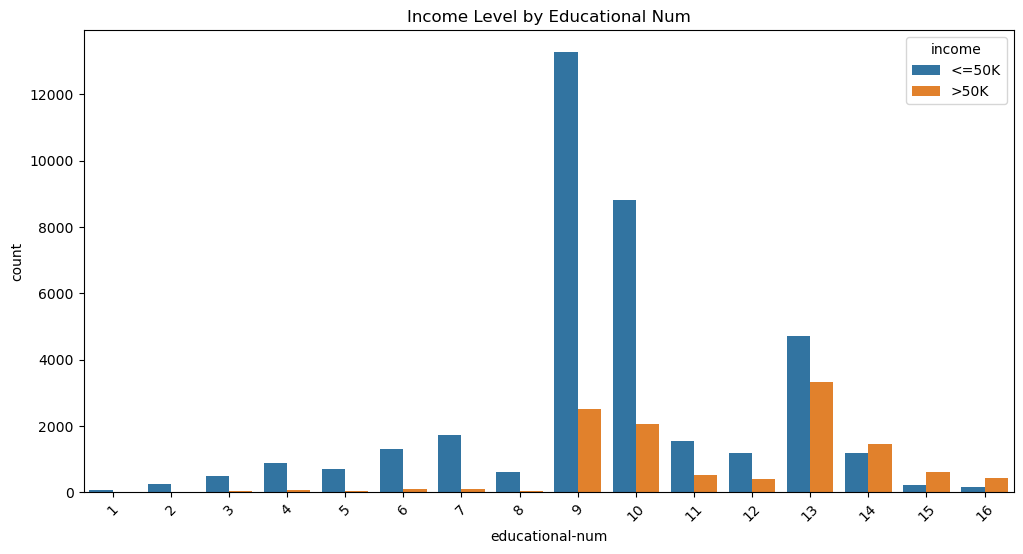

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='educational-num', hue='income')
plt.xticks(rotation=45)
plt.title('Income Level by Educational Num')
plt.show()

In [22]:
data = data.drop(columns="education", axis=1)
data = data.drop(columns=['fnlwgt'], axis=1)

In [23]:
data['net_capital'] = data['capital-gain'] - data['capital-loss']
data = data.drop(columns=['capital-gain', 'capital-loss'])

In [24]:
married_statuses = ['Married-civ-spouse', 'Married-AF-spouse', 'Married-spouse-absent']
data['marital_status_simple'] = data['marital-status'].apply(lambda x: 'Married' if x in married_statuses else 'Single')
data = data.drop(columns=['marital-status'])

In [25]:
data['country_simple'] = data['native-country'].apply(lambda x: 'US' if x == 'United-States' else 'Non-US')
data = data.drop(columns=['native-country'])

In [26]:
le = LabelEncoder()
data["income"] = le.fit_transform(data["income"])

In [27]:
data.shape

(48790, 12)

In [28]:
data.head()

,age,workclass,educational-num,occupation,relationship,race,gender,hours-per-week,income,net_capital,marital_status_simple,country_simple
0,25,Private,7,Machine-op-inspct,Own-child,Black,Male,40,0,0,Single,US
1,38,Private,9,Farming-fishing,Husband,White,Male,50,0,0,Married,US
2,28,Local-gov,12,Protective-serv,Husband,White,Male,40,1,0,Married,US
3,44,Private,10,Machine-op-inspct,Husband,Black,Male,40,1,7688,Married,US
4,18,Unknown,10,Unknown,Own-child,White,Female,30,0,0,Single,US


In [29]:
data.columns

Index(['age', 'workclass', 'educational-num', 'occupation', 'relationship',
       'race', 'gender', 'hours-per-week', 'income', 'net_capital',
       'marital_status_simple', 'country_simple'],
      dtype='object')

* **Feature Reduction**: Dropped `education` (redundant with `educational-num`) and `fnlwgt` (irrelevant instance weight).
* **Net Capital Calculation**: Combined `capital-gain` and `capital-loss` into a single `net_capital` feature (`capital-gain` - `capital-loss`).
* **Category Binned/Simplified**:
  * `marital-status`: Grouped into binary categories (`Married` vs `Single`).
  * `native-country`: Grouped into binary categories (`US` vs `Non-US`).
* **Target Encoding**: Encoded binary target column `income` using `LabelEncoder`.

In [30]:
X = data.drop("income", axis=1)

y = data["income"]

In [31]:
X

,age,workclass,educational-num,occupation,relationship,race,gender,hours-per-week,net_capital,marital_status_simple,country_simple
0,25,Private,7,Machine-op-inspct,Own-child,Black,Male,40,0,Single,US
1,38,Private,9,Farming-fishing,Husband,White,Male,50,0,Married,US
2,28,Local-gov,12,Protective-serv,Husband,White,Male,40,0,Married,US
3,44,Private,10,Machine-op-inspct,Husband,Black,Male,40,7688,Married,US
4,18,Unknown,10,Unknown,Own-child,White,Female,30,0,Single,US
...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,12,Tech-support,Wife,White,Female,38,0,Married,US
48838,40,Private,9,Machine-op-inspct,Husband,White,Male,40,0,Married,US
48839,58,Private,9,Adm-clerical,Unmarried,White,Female,40,0,Single,US
48840,22,Private,9,Adm-clerical,Own-child,White,Male,20,0,Single,US


In [32]:
y

0        0
1        0
2        1
3        1
4        0
        ..
48837    0
48838    1
48839    0
48840    0
48841    1
Name: income, Length: 48790, dtype: int64

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 🔢 Categorical Encoding & Feature Scaling
_______
Transform variables into numerical matrices without data leakage:


In [34]:
binary_cols = ['gender', 'marital_status_simple', 'country_simple']
onehot_cols = ['workclass', 'occupation', 'relationship', 'race']

ord_encoder = OrdinalEncoder()
ohe_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

In [35]:
X_train[binary_cols] = ord_encoder.fit_transform(X_train[binary_cols])
X_test[binary_cols] = ord_encoder.transform(X_test[binary_cols])

X_train_ohe = ohe_encoder.fit_transform(X_train[onehot_cols])
X_test_ohe = ohe_encoder.transform(X_test[onehot_cols])

In [36]:
ohe_feature_names = ohe_encoder.get_feature_names_out(onehot_cols)

X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_feature_names, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_feature_names, index=X_test.index)


X_train = X_train.drop(columns=onehot_cols).join(X_train_ohe_df)
X_test = X_test.drop(columns=onehot_cols).join(X_test_ohe_df)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (39032, 38)
X_test shape: (9758, 38)


In [37]:
X_train.head()

,age,educational-num,gender,hours-per-week,net_capital,marital_status_simple,country_simple,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,occupation_Unknown,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
13116,44,13,1.0,50,0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12057,22,13,0.0,20,0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
41063,29,13,0.0,42,0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
25025,22,9,1.0,50,0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4130,50,14,1.0,50,0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [38]:
X_test.head()

,age,educational-num,gender,hours-per-week,net_capital,marital_status_simple,country_simple,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,occupation_Unknown,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
30204,34,9,1.0,40,0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
26624,39,13,1.0,60,-1669,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
17977,49,9,0.0,43,0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
20164,63,6,1.0,40,0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10557,34,10,1.0,45,0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [39]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

* **Ordinal Encoding**: Applied to binary categorical variables (`gender`, `marital_status_simple`, `country_simple`).
* **One-Hot Encoding**: Applied to multi-class variables (`workclass`, `occupation`, `relationship`, `race`) with `drop='first'` and `handle_unknown='ignore'`.
* **Robust Scaling**: Applied `RobustScaler` on numerical columns to handle right-skewed feature distributions and heavy capital outliers.

In [64]:
knn = KNeighborsClassifier(n_neighbors=31)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=31)

In [65]:
y_pred = knn.predict(X_test)

In [66]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8626767780282845


In [67]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)


train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")

Train Accuracy: 0.8757
Test Accuracy:  0.8627


In [68]:
print( classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      7422
           1       0.74      0.65      0.69      2336

    accuracy                           0.86      9758
   macro avg       0.82      0.79      0.80      9758
weighted avg       0.86      0.86      0.86      9758



In [69]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6900  522]
 [ 818 1518]]


In [70]:
tn, fp, fn, tp = cm.ravel()

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

TN = 6900
FP = 522
FN = 818
TP = 1518


In [71]:
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31]}
knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"Best K found: {grid_search.best_params_['n_neighbors']}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_
y_pred_knn = best_knn.predict(X_test)

Best K found: 21
Best CV Accuracy: 0.8673


In [48]:
logistic_model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [49]:
y_pred = logistic_model.predict(X_test)
y_pred

array([0, 0, 1, ..., 0, 0, 1])

In [50]:
print('Model accuracy score: {0:0.2f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score: 0.84


In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      7422
           1       0.72      0.57      0.64      2336

    accuracy                           0.84      9758
   macro avg       0.80      0.75      0.77      9758
weighted avg       0.84      0.84      0.84      9758



In [60]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

In [61]:
print("--- Naive Bayes (Test Evaluation) ---")
print(classification_report(y_test, y_test_pred_nb))

--- Naive Bayes (Test Evaluation) ---
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      7422
           1       0.62      0.59      0.61      2336

    accuracy                           0.82      9758
   macro avg       0.75      0.74      0.74      9758
weighted avg       0.81      0.82      0.81      9758



## 📈 Receiver Operating Characteristic (ROC) Curve

We plot the **ROC Curve** and calculate the **AUC (Area Under the Curve)** score for all three models to compare their binary classification performance.

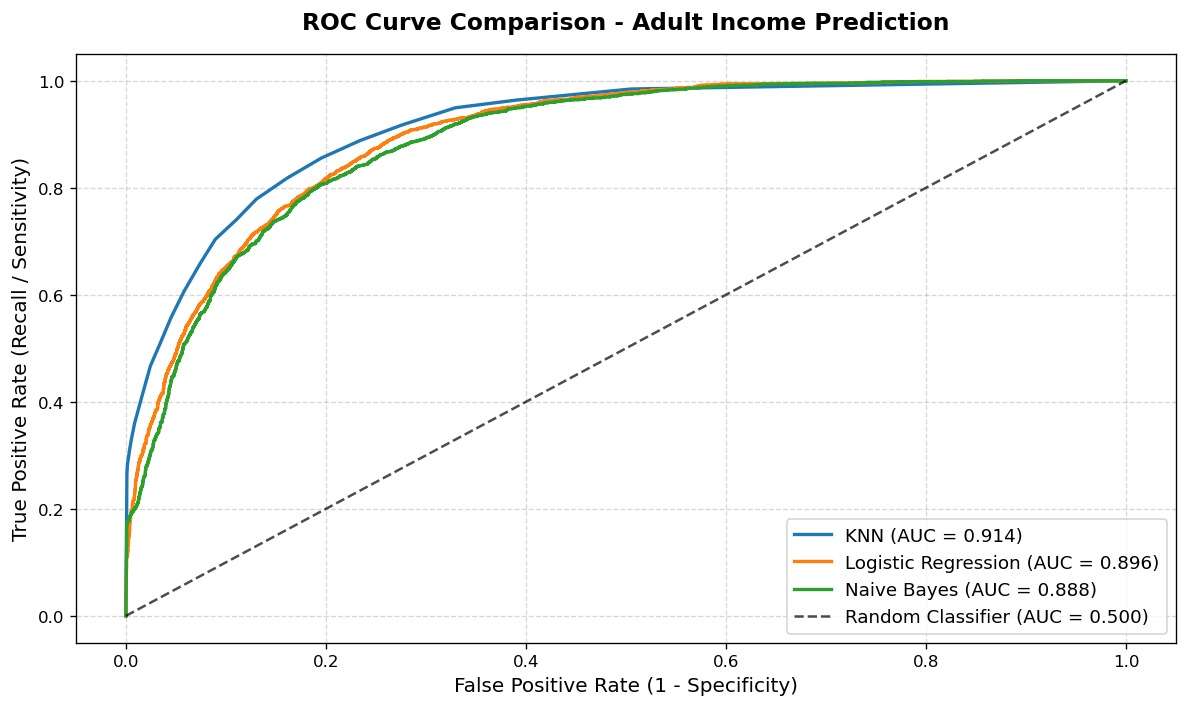

In [63]:
# 1. Get predicted probabilities for the positive class
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]  # استخدم best_knn هنا
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]
y_prob_nb  = nb_model.predict_proba(X_test)[:, 1]

# 2. Calculate False Positive Rate (fpr) & True Positive Rate (tpr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_nb,  tpr_nb,  _ = roc_curve(y_test, y_prob_nb)

# 3. Calculate AUC Scores
auc_knn = roc_auc_score(y_test, y_prob_knn)
auc_log = roc_auc_score(y_test, y_prob_log)
auc_nb  = roc_auc_score(y_test, y_prob_nb)

# 4. Plotting ROC Curves
plt.figure(figsize=(10, 6), dpi=120)

plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})', linewidth=2)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})', linewidth=2)

# Random Guess Reference Line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)', alpha=0.7)

# Styling
plt.title('ROC Curve Comparison - Adult Income Prediction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.legend(loc='lower right', fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 📝 ROC Curve Insights

* **AUC Score**: Measures the model's capability of distinguishing between classes. The closer to `1.0`, the better the performance.
* **Logistic Regression & KNN** typically yield the highest AUC scores (~$0.90+$), indicating strong class separation ability compared to Naive Bayes.

## 📊 Final Model Performance Summary

| Model | Hyperparameters / Details | Accuracy | Status |
| :--- | :--- | :--- | :--- |
| **KNN Classifier** | $K = 21$ | **~86.37%** | 🏆 Best Performance |
| **Logistic Regression** | `solver='liblinear'` | **~84%** | ⚡ Balanced & Fast |
| **Naive Bayes** | `BernoulliNB` | **~82%** | 🚀 Fastest Baseline |

### 💡 Key Takeaways & Conclusion

* **KNN ($K=31$)** provided the highest overall prediction accuracy on unseen test data.
* **Feature Simplification** (reducing marital status and native country categories) significantly reduced dataset sparsity and improved training stability across models.
  ____
  *Created with 💡 by **Makrix 🦉***